In [1]:
import os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
from torch.utils.data import DataLoader
import torch

from data import ForestDataset
from inference import SegmentationInference

from learn import *
from utils import *
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device {device}')

Using device cuda


In [2]:
# sanity check
amazon_train_img_files = os.listdir(os.path.join('AMAZON/Training', 'image'))
amazon_train_label_files = os.listdir(os.path.join('AMAZON/Training', 'label'))

atlantic_train_img_files = os.listdir(os.path.join('ATLANTIC/Training', 'image'))
atlantic_train_label_files =os.listdir(os.path.join('ATLANTIC/Training', 'label'))

print(set(amazon_train_img_files) == set(amazon_train_label_files), set(atlantic_train_img_files) == set(atlantic_train_label_files))

True True


In [3]:
print('Loading amazon model')
amazon_inference = SegmentationInference(get_model('cuda'), None,'checkpoints/Johnny_epoch30.pth', 'cuda')
#print('Loading atlantic model')
#atlantic_inference = SegmentationInference(get_model('cuda'), None,'checkpoints/Jimmy_epoch30.pth', 'cuda')

Loading amazon model


In [5]:
# cmap for fancier plots

# Method 1: Using ListedColormap (simplest approach)
def create_binary_cmap(color0='black', color1='white'):
    """Create a custom colormap for binary 0/1 values"""
    return mcolors.ListedColormap([color0, color1])

# Example usage
# Create the binary colormap
binary_cmap = create_binary_cmap(color0='darkgreen', color1='limegreen')

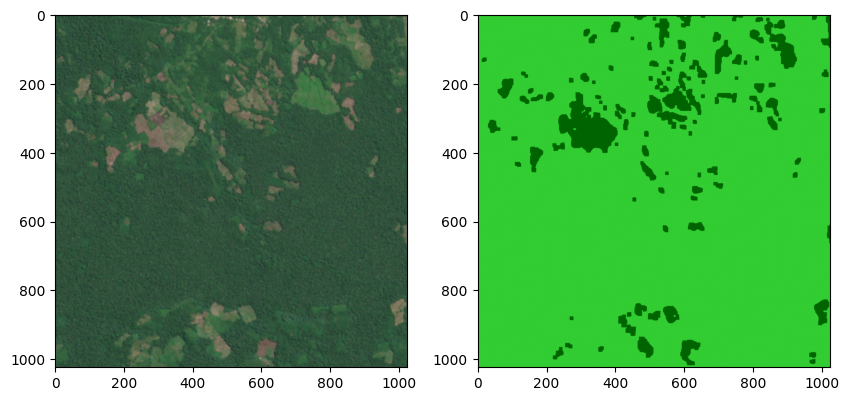

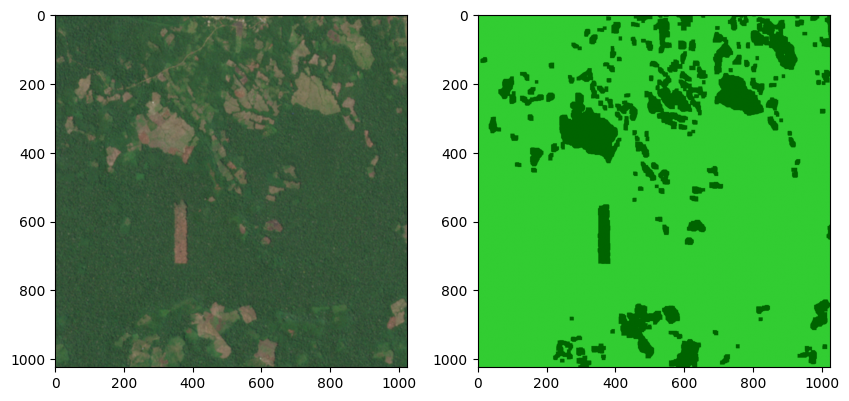

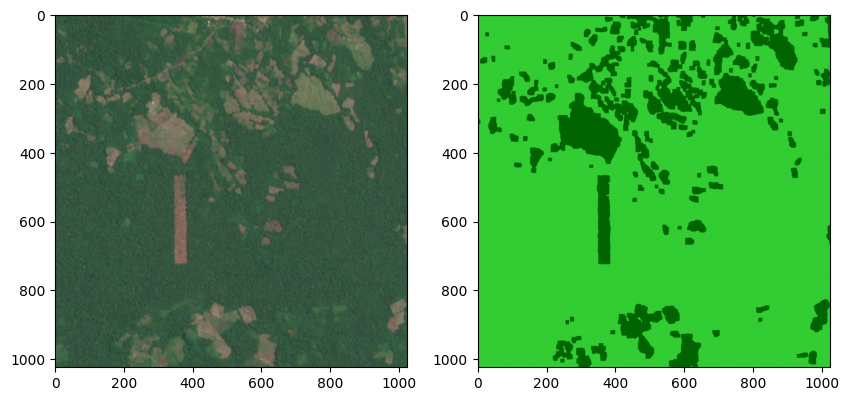

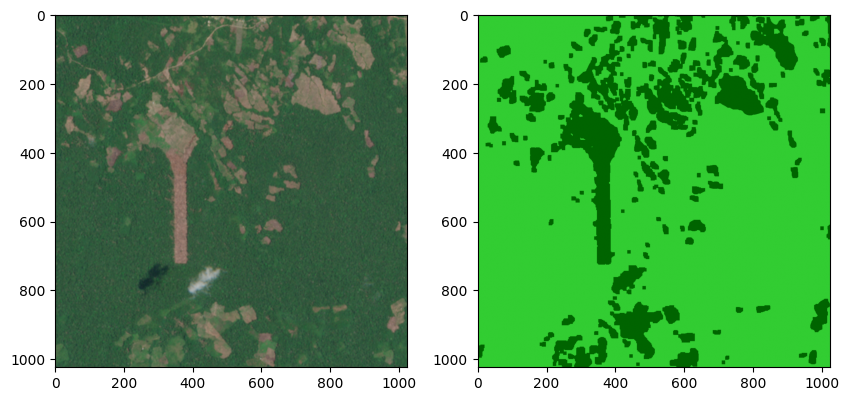

In [6]:
# test 1
for fname in os.listdir('amazon_test_0'):
    mask, img = amazon_inference(os.path.join('amazon_test_0', fname))

    fig, axes = plt.subplots(1,2, figsize=(10,5))
    axes[0].imshow(np.transpose(img, (1,2,0)))
    axes[1].imshow(mask, cmap=binary_cmap, vmin=0, vmax=1)

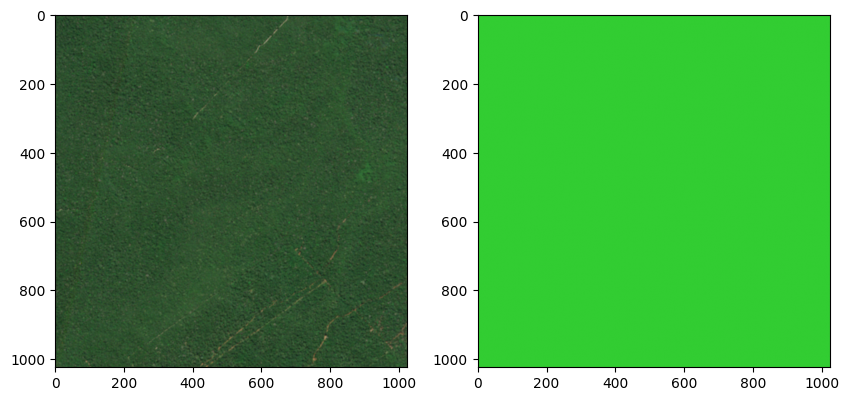

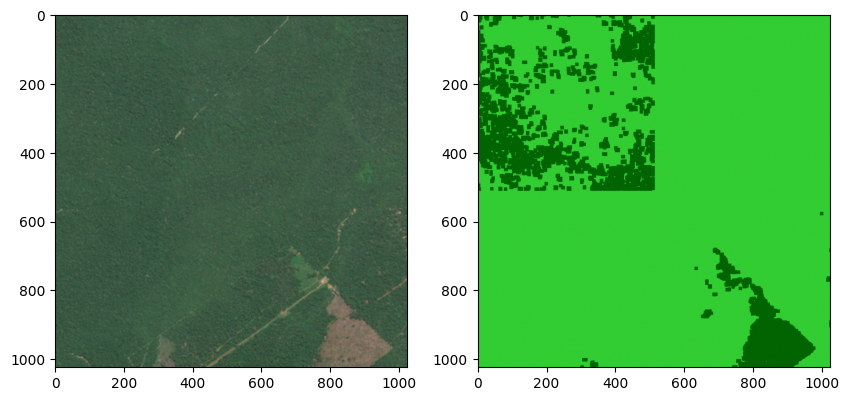

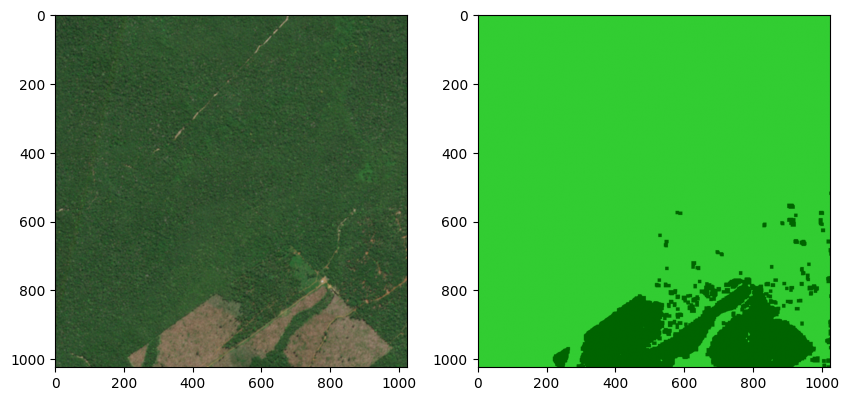

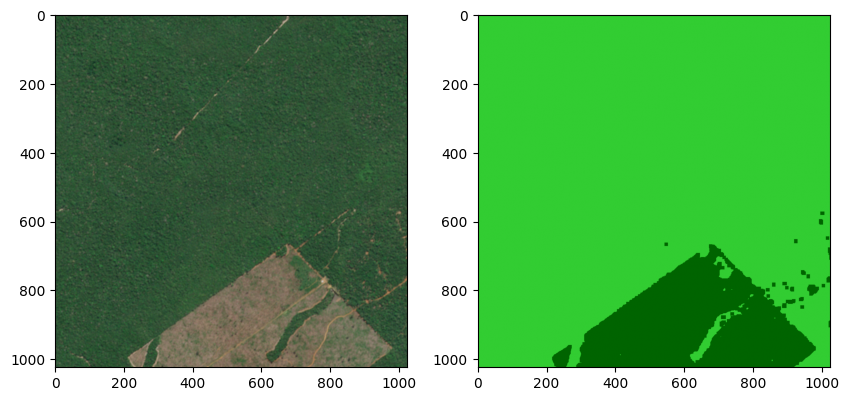

In [7]:
# test 1
for fname in os.listdir('amazon_test_1'):
    mask, img = amazon_inference(os.path.join('amazon_test_1', fname))
    fig, axes = plt.subplots(1,2, figsize=(10,5))
    axes[0].imshow(np.transpose(img, (1,2,0)))
    axes[1].imshow(mask, cmap=binary_cmap, vmin=0, vmax=1)